In [1]:
#import
import sys
import os

BASE_DIR = os.getcwd()

ROOT_DIR = os.path.abspath(os.path.join(BASE_DIR, '..'))

if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

import pandas as pd
import joblib
import warnings

warnings.filterwarnings("ignore")
from richieste.funzioni_commit import (create_all_base_features,
                                create_interactions,
                                final_preprocess,
                                plot_model_results,
                                detect_consistent_anomalies,
                                create_final_df
)

def ensure_const_and_align(X, const_name="const"):
    X = X.copy()

    # 1. Aggiunta esplicita della costante se manca
    if const_name not in X.columns:
        X.insert(0, const_name, 1.0)
        return X
    
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

In [7]:
MODEL_NAME = 'negbin+sarimax'
PROV    = "MI".upper()
COM     = 'F205'.upper()
ZONA    = 'R2'.upper()

START_TEST = pd.to_datetime("2025-11-01 00:00:00")
END_TEST =  pd.to_datetime("2025-11-29 23:00:00")

nome_modello = f'{PROV}_{COM}_{ZONA}_{MODEL_NAME}.pkl'

BASE_DIR = os.getcwd()
INPUT_DIR = os.path.join(BASE_DIR, "Modelli_traffico", PROV)
FILE_PATH = os.path.join(ROOT_DIR, "output_province", f"traffico_{PROV}.parquet")
INPUT_MODEL = os.path.join(INPUT_DIR, nome_modello)

parq = pd.read_parquet(FILE_PATH)

with open(INPUT_MODEL, 'rb') as f:
    loaded_predictor = joblib.load(f)

In [8]:
to_prep = parq[(parq['comune_amm'] == COM.upper()) & (parq['zona'] == ZONA.upper())]
df          = final_preprocess(to_prep, END_TEST)
base, info  = create_all_base_features(df, k_hour=4, k_week=2)
inter, _    = create_interactions(base, info)

X_global    = pd.concat([base, inter], axis=1)
y           = df['count_traffico']



X_global = X_global.copy()
X_test = X_global[df['datetime'].between(START_TEST, END_TEST)]
y_test = df[df['datetime'].between(START_TEST, END_TEST)]['count_traffico']
ds_test = df[df['datetime'].between(START_TEST, END_TEST)]['datetime']
print(f"Dimensioni df TRAIN con armoniche: {X_test.shape}, dimensioni serie storica: {y_test.shape}")

Creando feature base...

✓ 31 feature base create

✓ Totale 152 interazioni create

Dimensioni df TRAIN con armoniche: (696, 183), dimensioni serie storica: (696,)


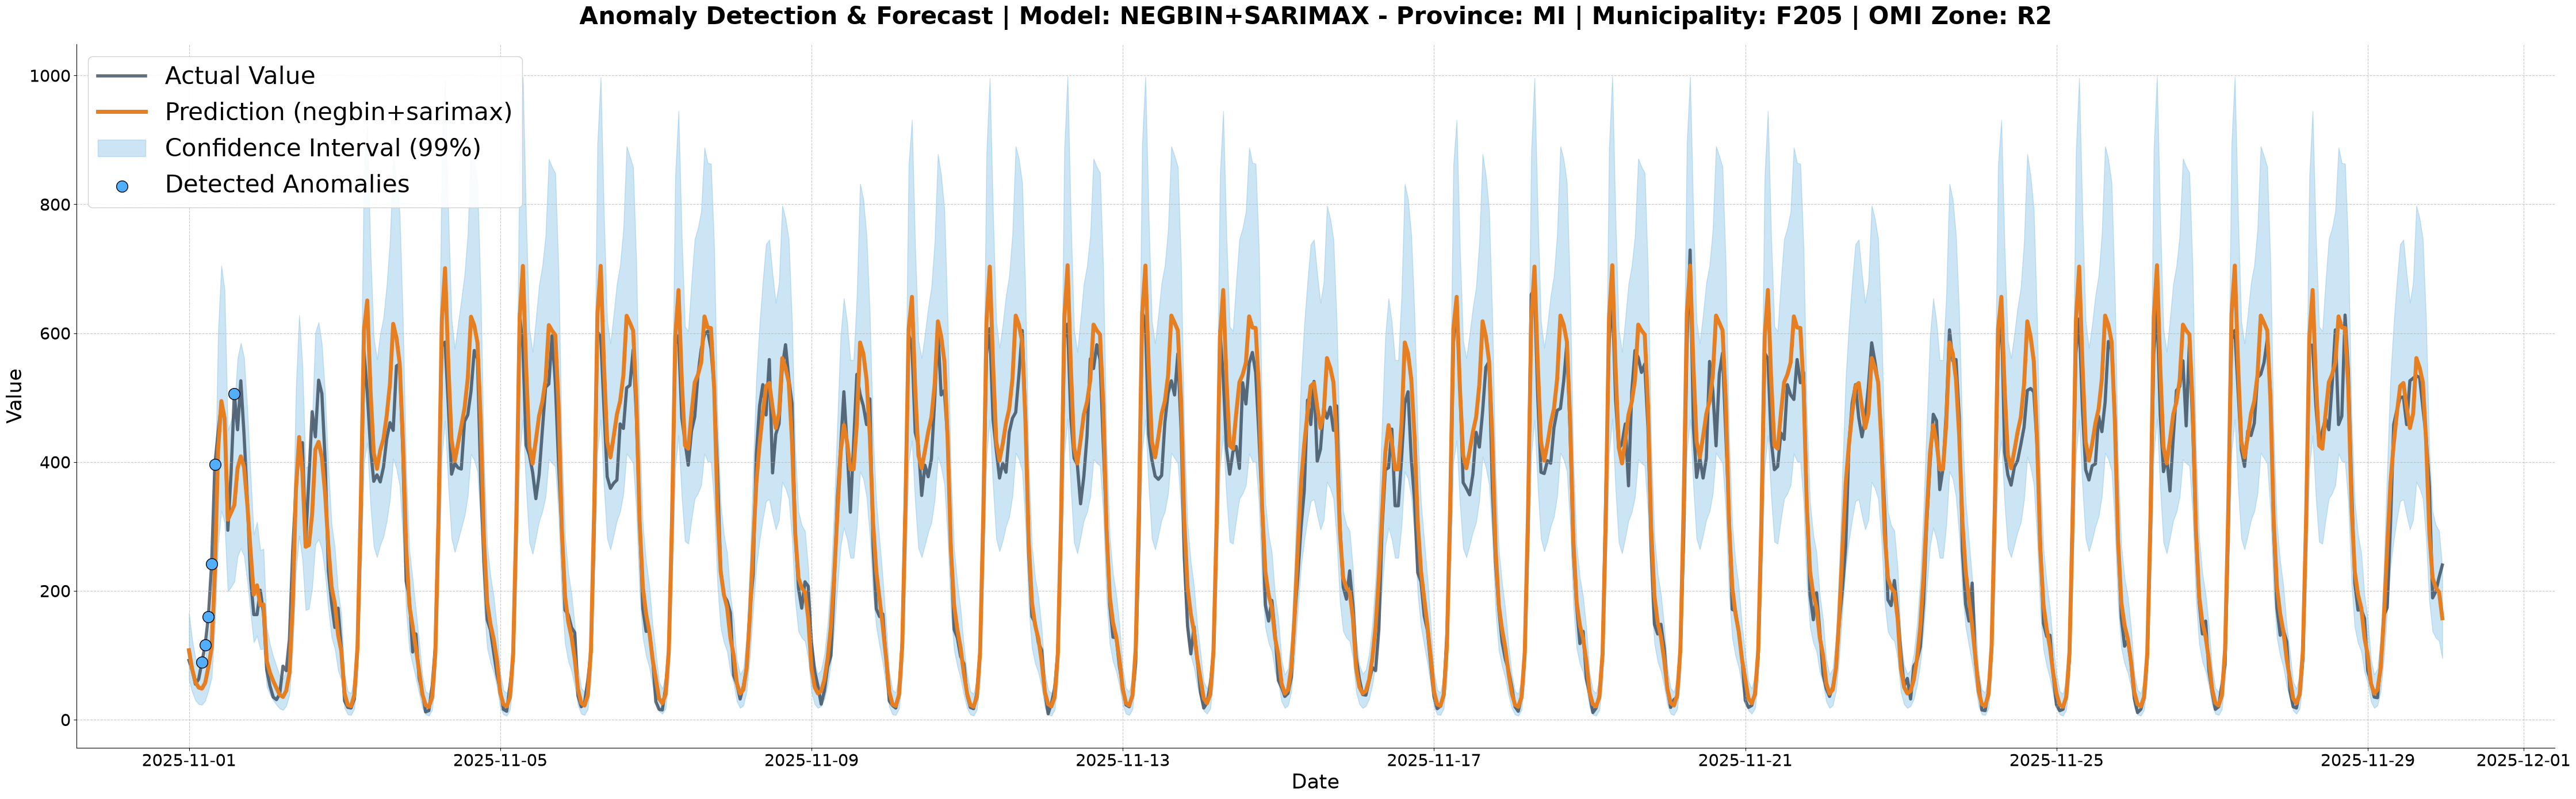

il numero assoluto di anomalie possibili è 6
il numero di anomalie possibili, in percentuale, è 0.8620689655172413%

Anomalie
il numero assoluto di anomalie probabili è 0
il numero di anomalie, in percentuale, è 0.0%


,ds,y_real,lower_99,y_pred,upper_99,is_anomaly,true_anomaly
4,2025-11-01 04:00:00,89.0,23.0,48.179092,81.0,True,False
5,2025-11-01 05:00:00,116.0,29.0,56.996228,94.0,True,False
6,2025-11-01 06:00:00,160.0,45.0,81.679169,129.0,True,False
7,2025-11-01 07:00:00,242.0,65.0,112.222831,172.0,True,False
8,2025-11-01 08:00:00,396.0,145.0,230.545923,337.0,True,False
14,2025-11-01 14:00:00,506.0,214.0,333.118923,480.0,True,False


In [9]:
# Applicazione
X_test_const = ensure_const_and_align(X_test)

results_df = loaded_predictor.predict(X_test = X_test_const,
                                      y_test = y_test,
                                      X_global = X_global,
                                      ds_test = ds_test,
                                      df = df)
results_df = detect_consistent_anomalies(results_df, min_daily_weight=4)

results_df.set_index('ds', inplace=True)
plot_model_results(results_df, MODEL_NAME, PROV, COM, ZONA)

results_df = results_df.reset_index(names = 'ds')
final_df = create_final_df(results_df)

anomalies = final_df[final_df['is_anomaly'] == True]
display(anomalies)

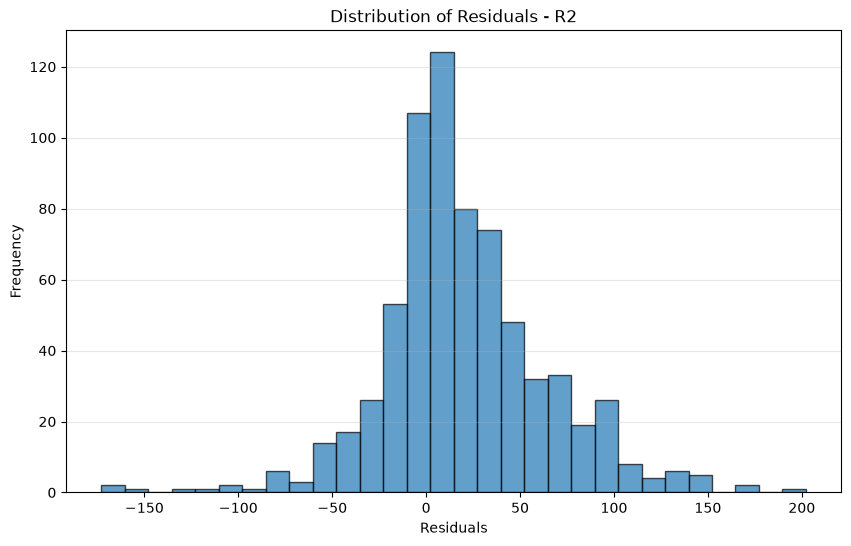

In [10]:
resid = final_df['y_pred'] - final_df['y_real']
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(resid, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title(f'Distribution of Residuals - {ZONA}')
plt.grid(axis='y', alpha=0.3)
plt.show()